<a href="https://colab.research.google.com/github/huseyinTozluyurt/Flyrank-Internship-MachineLearning/blob/main/work/notebooks/Predict_30d_Impressions_with_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # find the repo root from wherever this kernel started
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working dir:", os.getcwd())
assert os.path.exists("data/raw/content_refresh_anonymized.csv"), "starter CSV not found — are you at the repo root?"
print("Starter data found. You're ready.")

Working dir: /content/flyrank-ml-internship-starter
Starter data found. You're ready.


## Dataset Preperation and Importing Required Libraries

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

sns.set_theme(style="whitegrid")
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

**Can we predict the impressions that an article will receive in the last 30-day period using information from the previous 30 days and information about the content?**

### Exploring Missing Values
Let's check which columns contain missing values and their respective counts/percentages to decide on the best imputation strategies.

In [5]:
# Calculate missing value percentage per column
missing_info = df.isnull().sum()
missing_percent = 100 * df.isnull().sum() / len(df)
missing_table = pd.concat([missing_info, missing_percent], axis=1, keys=['Missing Values', '% of Total'])
missing_table = missing_table[missing_table['Missing Values'] > 0].sort_values('% of Total', ascending=False)

display(missing_table)

,Missing Values,% of Total
provider_used,21438,71.460000
word_count_tier,7699,25.663333
char_count,7699,25.663333
word_count,7699,25.663333
char_count_tier,7699,25.663333
model_used,5733,19.110000
trend_pct,3388,11.293333
competition_level,2610,8.700000
search_volume,2468,8.226667
competition,2468,8.226667


## Handling Missing Values & Implementing Imputation
1. **Numerical features**: Median imputation for missing numerical features
2. **Categorical features**: Mode / Frequency based imputation for missing categorical features

In [6]:
# Identify numerical and categorical columns with missing values
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Exclude target/ID columns from automatic imputation if necessary
# (e.g., content_id, client_id)
if 'content_id' in categorical_cols: categorical_cols.remove('content_id')
if 'client_id' in categorical_cols: categorical_cols.remove('client_id')

# Define simple imputers
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

# Apply imputation
df_imputed = df.copy()
if numerical_cols:
    df_imputed[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])
if categorical_cols:
    df_imputed[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Confirm that no missing values remain in the imputed features
remaining_missing = df_imputed.isnull().sum().sum()
print(f"Total missing values after imputation: {remaining_missing}")
display(df_imputed.head())

Total missing values after imputation: 0


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,2877.0,19116.0,...,15000-25000,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


### Define Features and Target
Extracting the feature lists and target variable as defined in the regression script.

In [7]:
TARGET = "impressions_last_30d"

NUMERIC_FEATURES = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "avg_position",
]

CATEGORICAL_FEATURES = [
    "competition_level",
    "content_type",
    "main_intent",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

### Train-Test Split
Separating the data into training (80%) and testing (20%) sets.

In [8]:
# To avoid DATA LEAKAGE, we must split the raw data BEFORE any imputation.
# The scikit-learn Pipeline we define later will handle the imputation properly
# (fitting only on the training set and transforming the test set).
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (24000, 14)
Testing set shape: (6000, 14)


### Build Pipeline and Train Model
Constructing the `ColumnTransformer` for preprocessing (OneHotEncoding categorical variables) and combining it with the `XGBRegressor` in a Scikit-Learn `Pipeline`.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUMERIC_FEATURES),
        ("cat", categorical_transformer, CATEGORICAL_FEATURES),
    ]
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(random_state=42, n_estimators=100))
])

# Train the model on the updated leakage-free data
pipeline.fit(X_train, y_train)
print("Model training completed on leakage-free data.")

Model training completed on leakage-free data.


### Evaluate Model
Making predictions on the test set and computing MAE, RMSE, and R-squared metrics.

In [10]:
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Leakage-Free XGBoost MAE  : {mae:,.2f}")
print(f"Leakage-Free XGBoost RMSE : {rmse:,.2f}")
print(f"Leakage-Free XGBoost R²   : {r2:.4f}")

Leakage-Free XGBoost MAE  : 567.35
Leakage-Free XGBoost RMSE : 2,900.18
Leakage-Free XGBoost R²   : 0.7366


### Check for Overfitting (Train vs Test Performance)
Evaluating the model on the training set to compare its performance against the test set.

In [11]:
y_train_pred = pipeline.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("--- Leakage-Free Training Set Performance ---")
print(f"Train MAE  : {train_mae:,.2f}")
print(f"Train RMSE : {train_rmse:,.2f}")
print(f"Train R²   : {train_r2:.4f}")

print("\n--- Leakage-Free Test Set Performance ---")
print(f"Test MAE   : {mae:,.2f}")
print(f"Test RMSE  : {rmse:,.2f}")
print(f"Test R²    : {r2:.4f}")

--- Leakage-Free Training Set Performance ---
Train MAE  : 248.95
Train RMSE : 594.36
Train R²   : 0.9889

--- Leakage-Free Test Set Performance ---
Test MAE   : 567.35
Test RMSE  : 2,900.18
Test R²    : 0.7366


### Hyperparameter Tuning (Addressing Overfitting)
Since the model is heavily overfitting the training set (Train R² ~ 0.99 vs Test R² ~ 0.74), let's tune some key XGBoost hyperparameters to constrain the model's complexity.

In [12]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter grid to search over
# These parameters specifically help in reducing overfitting
param_dist = {
    'regressor__n_estimators': randint(50, 200),
    'regressor__max_depth': randint(3, 8),
    'regressor__learning_rate': uniform(0.01, 0.2),
    'regressor__subsample': uniform(0.6, 0.4),
    'regressor__colsample_bytree': uniform(0.6, 0.4),
    'regressor__min_child_weight': randint(1, 10),
    'regressor__gamma': uniform(0, 5)
}

# Initialize RandomizedSearchCV
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20, # Number of parameter settings that are sampled
    cv=3,      # 3-fold cross-validation
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)
print("Tuning complete.")

# Best parameters and score
print("\nBest parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param}: {value}")


Starting hyperparameter tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Tuning complete.

Best parameters found:
  regressor__colsample_bytree: 0.9329770563201687
  regressor__gamma: 1.0616955533913808
  regressor__learning_rate: 0.04636499344142013
  regressor__max_depth: 7
  regressor__min_child_weight: 1
  regressor__n_estimators: 107
  regressor__subsample: 0.8099025726528951


In [13]:
# Evaluate the tuned model
best_pipeline = random_search.best_estimator_

# Predictions on Train and Test sets
tuned_y_train_pred = best_pipeline.predict(X_train)
tuned_y_pred = best_pipeline.predict(X_test)

# Calculate metrics
tuned_train_mae = mean_absolute_error(y_train, tuned_y_train_pred)
tuned_train_rmse = np.sqrt(mean_squared_error(y_train, tuned_y_train_pred))
tuned_train_r2 = r2_score(y_train, tuned_y_train_pred)

tuned_mae = mean_absolute_error(y_test, tuned_y_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_y_pred))
tuned_r2 = r2_score(y_test, tuned_y_pred)

print("--- Tuned Training Set Performance ---")
print(f"Train MAE  : {tuned_train_mae:,.2f}")
print(f"Train RMSE : {tuned_train_rmse:,.2f}")
print(f"Train R²   : {tuned_train_r2:.4f}")

print("\n--- Tuned Test Set Performance ---")
print(f"Test MAE   : {tuned_mae:,.2f}")
print(f"Test RMSE  : {tuned_rmse:,.2f}")
print(f"Test R²    : {tuned_r2:.4f}")


--- Tuned Training Set Performance ---
Train MAE  : 381.42
Train RMSE : 1,190.55
Train R²   : 0.9555

--- Tuned Test Set Performance ---
Test MAE   : 560.53
Test RMSE  : 2,964.94
Test R²    : 0.7247


### Feature Importances
Extracting feature importances from the trained XGBoost model to see which features are most predictive of future impressions.

/tmp/ipykernel_1871/1325657644.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


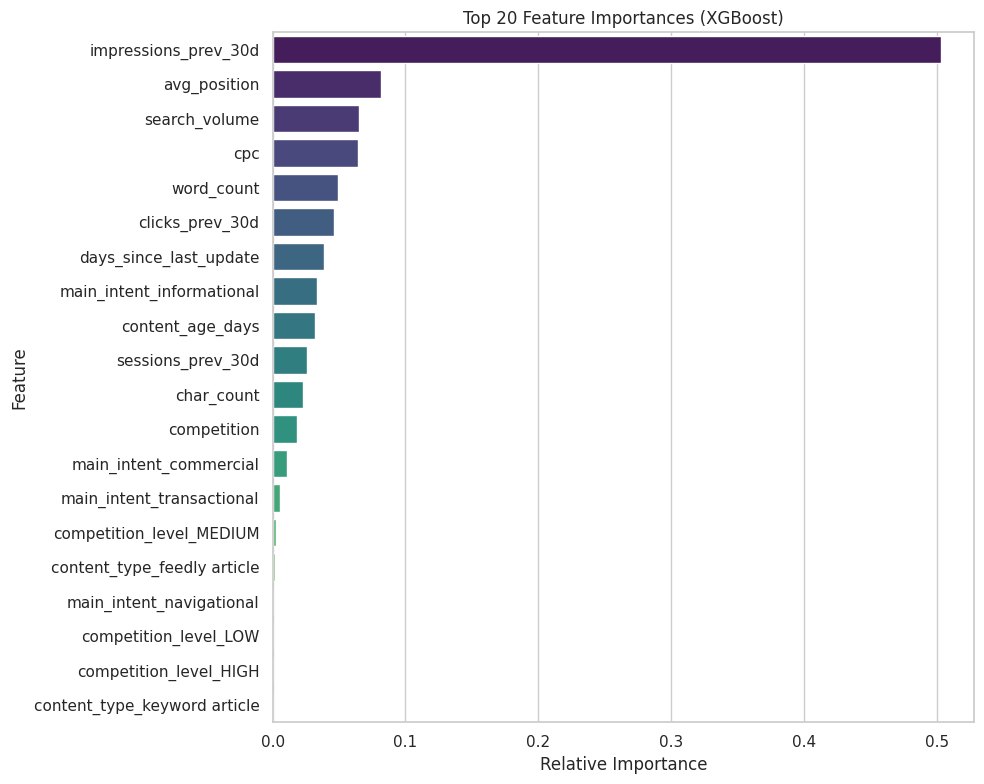

In [14]:
# Extract the preprocessor and regressor from the pipeline
preprocessor = pipeline.named_steps['preprocessor']
regressor = pipeline.named_steps['regressor']

# Get feature names out of the ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

# Clean feature names (remove 'num__' and 'cat__' prefixes for readability)
clean_feature_names = [name.split('__')[-1] for name in feature_names]

# Create a DataFrame for importances
importance_df = pd.DataFrame({
    'Feature': clean_feature_names,
    'Importance': regressor.feature_importances_
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 20 feature importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## DuckDB Full-Release Dataset with 79M rows

In [15]:
%pip -q install duckdb huggingface_hub


In [16]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')


Paste your Hugging Face READ token (hf_...): ··········


In [17]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')


dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


In [18]:
clients = con.sql(f"""
    SELECT client_hash_id, access_profile, gsc_data_start, ga4_data_start
    FROM {TABLES['dim_clients']}
    ORDER BY gsc_data_start NULLS LAST
""").df()

print('clients with 12+ months of GSC history:',
      (clients['gsc_data_start'] <= clients['gsc_data_start'].dropna().max() - __import__('pandas').Timedelta(days=365)).sum())
clients.head(10)


clients with 12+ months of GSC history: 4


,client_hash_id,access_profile,gsc_data_start,ga4_data_start
0,client_9958f0a7ae1df715,gsc_and_ga4,2025-01-27,2025-10-29
1,client_ff644d8251367cbb,gsc_and_ga4,2025-01-27,2025-10-29
2,client_73cda7b4e4f265ea,gsc_and_ga4,2025-02-11,2026-03-24
3,client_fef1a8f436438636,gsc_and_ga4,2025-03-11,2026-03-06
4,client_62f4a7e64f5e0096,gsc_only,2025-06-07,NaT
5,client_b10cb2997d0c7c86,gsc_and_ga4,2025-06-18,2025-11-15
6,client_65de48885f4ef01b,gsc_and_ga4,2025-06-21,2026-02-19
7,client_c182d11e4862a37d,gsc_and_ga4,2025-06-21,2026-02-20
8,client_3197e6291363b4db,gsc_and_ga4,2025-06-29,2025-11-09
9,client_625b6439094e23e4,gsc_and_ga4,2025-07-01,2026-02-19


In [19]:
features = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    ),
    windowed AS (
        SELECT f.client_hash_id, f.content_hash_id,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_last30,
               SUM(CASE WHEN f.report_date <= b.end_d - INTERVAL 30 DAY THEN f.gsc_impressions ELSE 0 END) AS imp_prev30,
               SUM(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_clicks ELSE 0 END)      AS clk_last30,
               AVG(CASE WHEN f.report_date >  b.end_d - INTERVAL 30 DAY THEN f.gsc_avg_position END)       AS pos_last30
        FROM {TABLES['fact_daily']} f, bounds b
        WHERE f.report_date > b.end_d - INTERVAL 90 DAY
        GROUP BY 1, 2
        HAVING imp_prev30 >= 100
    )
    SELECT * FROM windowed
""").df()

print(f'{len(features):,} content items with enough history')
features.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

136,252 content items with enough history


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30
0,client_3ffa76342f366962,content_b89167cd03d6ffc1,12.0,102.0,1.0,5.104167
1,client_3ffa76342f366962,content_f33fd2cd160185e7,41.0,130.0,0.0,6.323529
2,client_e547b89c05043229,content_2e296120acb03e93,2346.0,5207.0,0.0,38.156281
3,client_e547b89c05043229,content_516b7c0e8eec0cef,371.0,2494.0,0.0,48.364954
4,client_e547b89c05043229,content_38b6c1a9aa29f801,5746.0,12657.0,2.0,40.082120


In [20]:
position_volatility = con.sql(f"""
    WITH bounds AS (
        SELECT MAX(report_date) AS end_d FROM {TABLES['fact_daily']}
    )
    SELECT f.client_hash_id, f.content_hash_id,
           STDDEV(f.gsc_avg_position) AS pos_volatility_90d
    FROM {TABLES['fact_daily']} f, bounds b
    WHERE f.report_date > b.end_d - INTERVAL 90 DAY
    GROUP BY 1, 2
""").df()

print(f'{len(position_volatility):,} content items with position volatility data')
position_volatility.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

409,326 content items with position volatility data


,client_hash_id,content_hash_id,pos_volatility_90d
0,client_3ffa76342f366962,content_3626d7273836abfc,7.211103
1,client_3ffa76342f366962,content_2213d66abccd599d,4.509250
2,client_3ffa76342f366962,content_4e06f4b2f1930406,4.041452
3,client_3ffa76342f366962,content_6324839bada7c8e2,NaN
4,client_3ffa76342f366962,content_ae3d2bda17385c29,NaN


In [21]:
qsignals = con.sql(f"""
    SELECT content_hash_id,
           ANY_VALUE(content_visible_query_count)     AS visible_queries,
           ANY_VALUE(rare_impressions_share)          AS rare_share,
           ANY_VALUE(anonymized_impressions_share)    AS anon_share,
           MAX(impressions_90d)                       AS top_query_impressions,
           SUM(impressions_90d)                       AS kept_impressions
    FROM {TABLES['fact_query_90d']}
    GROUP BY content_hash_id
""").df()

qsignals['top_query_share'] = qsignals['top_query_impressions'] / qsignals['kept_impressions']
data = features.merge(qsignals, on='content_hash_id', how='left')
data = data.merge(position_volatility, on=['client_hash_id', 'content_hash_id'], how='left')
print(f'joined: {len(data):,} rows')
data.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

joined: 136,252 rows


,client_hash_id,content_hash_id,imp_last30,imp_prev30,clk_last30,pos_last30,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share,pos_volatility_90d
0,client_3ffa76342f366962,content_b89167cd03d6ffc1,12.0,102.0,1.0,5.104167,NaN,NaN,NaN,NaN,NaN,NaN,3.133931
1,client_3ffa76342f366962,content_f33fd2cd160185e7,41.0,130.0,0.0,6.323529,NaN,NaN,NaN,NaN,NaN,NaN,2.841835
2,client_e547b89c05043229,content_2e296120acb03e93,2346.0,5207.0,0.0,38.156281,43.0,0.042632,0.545876,409.0,3108.0,0.131596,9.232266
3,client_e547b89c05043229,content_516b7c0e8eec0cef,371.0,2494.0,0.0,48.364954,13.0,0.112391,0.679232,305.0,597.0,0.510888,13.601872
4,client_e547b89c05043229,content_38b6c1a9aa29f801,5746.0,12657.0,2.0,40.082120,129.0,0.069119,0.517198,1398.0,7613.0,0.183633,9.400494


In [22]:
import duckdb

# We already have `data` dataframe from previous cells with many features.
# Let's ensure it has exactly the columns the model expects.

# Map from our DuckDB queried names to the expected feature names.
duckdb_feature_mapping = {
    'imp_prev30': 'impressions_prev_30d',
    'clk_last30': 'clicks_prev_30d', # the SQL used 'clk_last30' for > end-30. Wait, previous SQL used 'clk_last30' for the wrong window if it meant previous 30.
    # Let's re-query properly based on the script.
}


In [23]:
query = f"""
WITH bounds AS (
    SELECT MAX(CAST(f.report_date AS DATE)) AS end_date
    FROM {TABLES['fact_daily']} f
),
performance AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY
                  AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS impressions_prev_30d,
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY
                  AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clicks_prev_30d,
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY
                  AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.ga4_sessions, 0) ELSE 0 END) AS sessions_prev_30d,
        AVG(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY
                  AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN f.gsc_avg_position END) AS avg_position,
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS impressions_last_30d
    FROM {TABLES['fact_daily']} f
    CROSS JOIN bounds b
    WHERE CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY
    GROUP BY f.client_hash_id, f.content_hash_id
)
SELECT
    p.*,
    c.search_volume,
    c.competition,
    c.cpc,
    c.word_count,
    c.char_count,
    DATE_DIFF('day', CAST(c.content_created_date AS DATE), (SELECT end_date FROM bounds)) AS content_age_days,
    DATE_DIFF('day', CAST(c.content_updated_date AS DATE), (SELECT end_date FROM bounds)) AS days_since_last_update,
    c.competition_level,
    c.content_type,
    c.main_intent
FROM performance p
LEFT JOIN {TABLES['dim_content']} c ON p.content_hash_id = c.content_hash_id
WHERE p.impressions_prev_30d >= 100
"""

print("Executing 60-day aggregation in DuckDB...")
duckdb_eval_data = con.sql(query).df()
print(f"DuckDB evaluation rows: {len(duckdb_eval_data):,}")

Executing 60-day aggregation in DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

DuckDB evaluation rows: 111,247


In [24]:
# Validate and clean data
duckdb_eval_data = duckdb_eval_data.dropna(subset=[TARGET])
duckdb_eval_data = duckdb_eval_data[duckdb_eval_data[TARGET] >= 0]

print(f"Rows after cleaning: {len(duckdb_eval_data):,}")

# Predict using the FROZEN pipeline trained on CSV
X_duckdb = duckdb_eval_data[FEATURES]
duckdb_predictions = pipeline.predict(X_duckdb)

# Because the target was raw impressions (not log transformed in our notebook implementation),
# we predict directly.
duckdb_predictions = np.maximum(duckdb_predictions, 0)

print("Predictions generated on DuckDB data.")

Rows after cleaning: 111,247
Predictions generated on DuckDB data.


In [25]:
# Evaluate vs Baseline
actual_duckdb = duckdb_eval_data[TARGET].to_numpy()

def calc_metrics(act, pred):
    return {
        'MAE': mean_absolute_error(act, pred),
        'RMSE': np.sqrt(mean_squared_error(act, pred)),
        'R2': r2_score(act, pred)
    }

model_metrics = calc_metrics(actual_duckdb, duckdb_predictions)

# Naive baseline: future 30d impressions = previous 30d impressions
baseline_preds = duckdb_eval_data['impressions_prev_30d'].fillna(0).to_numpy()
baseline_metrics = calc_metrics(actual_duckdb, baseline_preds)

comparison_df = pd.DataFrame({
    'Model': ['Naive Baseline', 'CSV-trained XGBoost'],
    'MAE': [baseline_metrics['MAE'], model_metrics['MAE']],
    'RMSE': [baseline_metrics['RMSE'], model_metrics['RMSE']],
    'R2': [baseline_metrics['R2'], model_metrics['R2']]
})

display(comparison_df)

,Model,MAE,RMSE,R2
0,Naive Baseline,1114.129217,4135.184804,0.626986
1,CSV-trained XGBoost,1099.210459,5235.358481,0.402100


In [26]:
# Create a DataFrame to view the individual prediction results
results_df = duckdb_eval_data[['client_hash_id', 'content_hash_id', TARGET, 'impressions_prev_30d', 'avg_position']].copy()
results_df['predicted_impressions_last_30d'] = duckdb_predictions

# Calculate the absolute error for each prediction
results_df['absolute_error'] = (results_df[TARGET] - results_df['predicted_impressions_last_30d']).abs()

# Display the first 15 rows of the results
display(results_df.head(15))

,client_hash_id,content_hash_id,impressions_last_30d,impressions_prev_30d,avg_position,predicted_impressions_last_30d,absolute_error
0,client_06d356715a8ff3b6,content_0059a4d4195810c9,845.0,1108.0,17.658602,397.526825,447.473175
1,client_06d356715a8ff3b6,content_005b6b7f7b8dda7f,957.0,1535.0,9.986717,1013.066772,56.066772
2,client_06d356715a8ff3b6,content_00a34394d4ee05ce,142.0,248.0,29.464602,86.653954,55.346046
3,client_06d356715a8ff3b6,content_0153b7dedc3fc40d,695.0,2297.0,8.294681,1191.789062,496.789062
4,client_06d356715a8ff3b6,content_0170639e18314d31,517.0,157.0,8.392896,12.237430,504.762570
5,client_06d356715a8ff3b6,content_01ad5f3e74c28a0d,797.0,1148.0,9.426241,920.818481,123.818481
6,client_06d356715a8ff3b6,content_01c33f536772b193,1790.0,316.0,9.025515,191.114395,1598.885605
7,client_06d356715a8ff3b6,content_01d2f71b5d275c1c,944.0,254.0,12.035592,186.328003,757.671997
8,client_06d356715a8ff3b6,content_01d39db71637411b,4406.0,423.0,7.730463,455.720398,3950.279602
9,client_06d356715a8ff3b6,content_01ed88e884c2e091,715.0,402.0,35.348708,268.760071,446.239929


You can also sort the dataframe to see where the model made the biggest errors, or how it performed on the most popular content. For example, to see the predictions for the content with the highest actual impressions:

```python
display(results_df.sort_values(by=TARGET, ascending=False).head(10))
```

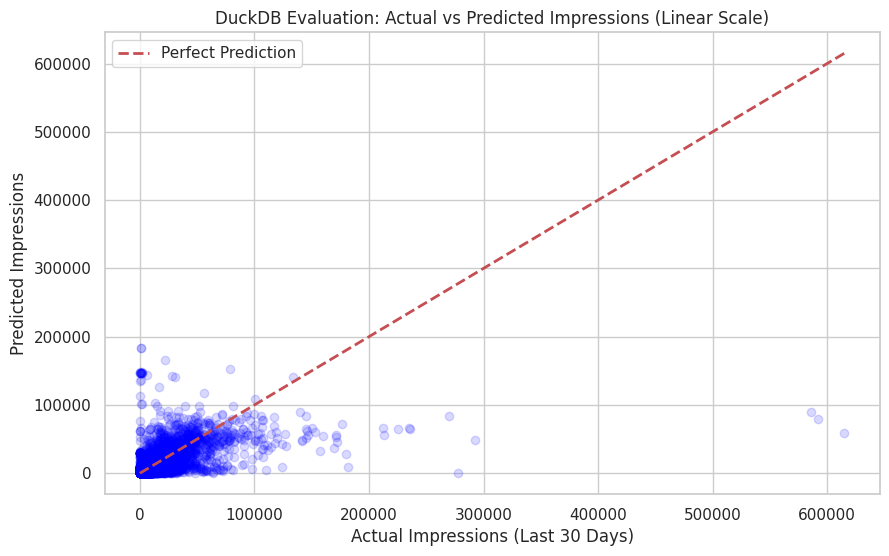

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_theme(style="whitegrid")

# 1. Actual vs Predicted (Linear Scale)
plt.figure(figsize=(10, 6))
plt.scatter(actual_duckdb, duckdb_predictions, alpha=0.15, color='blue')
max_val = max(np.max(actual_duckdb), np.max(duckdb_predictions))
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.title('DuckDB Evaluation: Actual vs Predicted Impressions (Linear Scale)')
plt.xlabel('Actual Impressions (Last 30 Days)')
plt.ylabel('Predicted Impressions')
plt.legend()
plt.show()

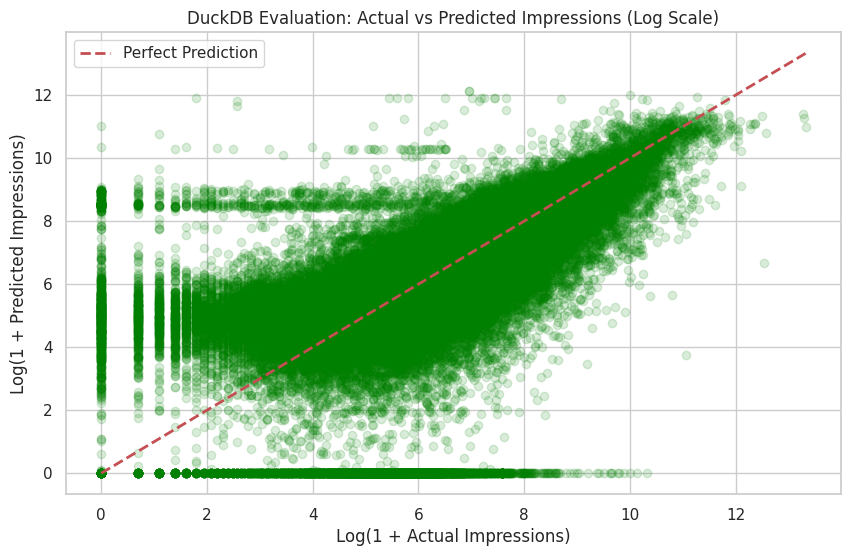

In [28]:
# 2. Actual vs Predicted (Log Scale)
plt.figure(figsize=(10, 6))
# Apply log1p (log(1+x)) to handle zero values safely
log_actual = np.log1p(actual_duckdb)
log_pred = np.log1p(duckdb_predictions)

plt.scatter(log_actual, log_pred, alpha=0.15, color='green')
max_log_val = max(np.max(log_actual), np.max(log_pred))
plt.plot([0, max_log_val], [0, max_log_val], 'r--', lw=2, label='Perfect Prediction')
plt.title('DuckDB Evaluation: Actual vs Predicted Impressions (Log Scale)')
plt.xlabel('Log(1 + Actual Impressions)')
plt.ylabel('Log(1 + Predicted Impressions)')
plt.legend()
plt.show()

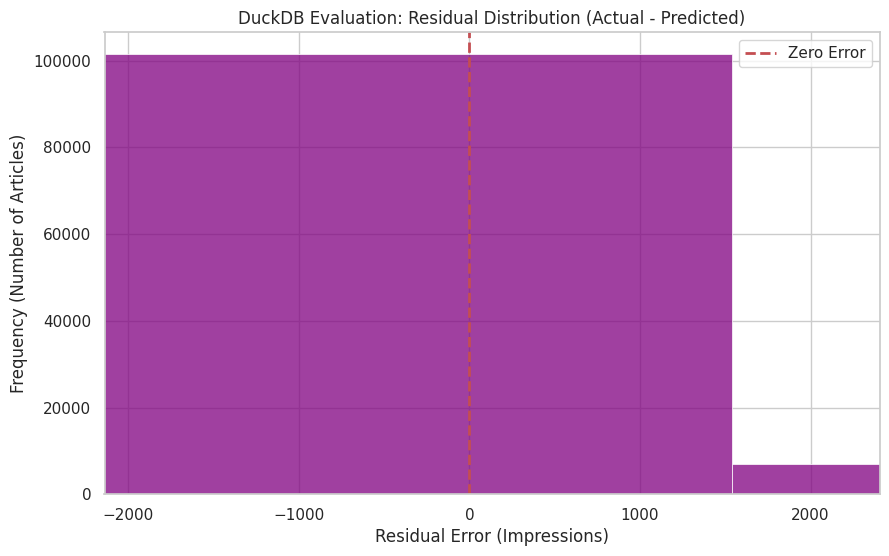

In [29]:
# 3. Residual Distribution
residuals = actual_duckdb - duckdb_predictions

plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=100, color='purple')
plt.axvline(0, color='r', linestyle='--', lw=2, label='Zero Error')
plt.title('DuckDB Evaluation: Residual Distribution (Actual - Predicted)')
plt.xlabel('Residual Error (Impressions)')
plt.ylabel('Frequency (Number of Articles)')

# Zoom in on the bulk of the distribution if there are extreme outliers
percentile_5 = np.percentile(residuals, 5)
percentile_95 = np.percentile(residuals, 95)
plt.xlim(percentile_5, percentile_95)

plt.legend()
plt.show()

In [30]:
import joblib
from pathlib import Path
import os
import pandas as pd

# Ensure output directory exists
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define paths
MODEL_PATH = OUTPUT_DIR / "content_impressions_xgboost_model.joblib"
DUCKDB_RESULTS_PATH = OUTPUT_DIR / "duckdb_predictions.csv"
METRICS_PATH = OUTPUT_DIR / "evaluation_metrics.csv"

# Save the model pipeline
joblib.dump(pipeline, MODEL_PATH)
print(f"Model saved successfully to {MODEL_PATH}")

# Save DuckDB predictions
results_df.to_csv(DUCKDB_RESULTS_PATH, index=False)
print(f"DuckDB predictions saved to {DUCKDB_RESULTS_PATH}")

# Save metrics
metrics_table = pd.DataFrame([
    {
        "dataset": "DuckDB",
        "model": "Naive Baseline",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"],
        "R2": baseline_metrics["R2"],
    },
    {
        "dataset": "DuckDB",
        "model": "CSV-trained XGBoost",
        "MAE": model_metrics["MAE"],
        "RMSE": model_metrics["RMSE"],
        "R2": model_metrics["R2"],
    }
])
metrics_table.to_csv(METRICS_PATH, index=False)
print(f"Metrics saved to {METRICS_PATH}")

Model saved successfully to outputs/content_impressions_xgboost_model.joblib
DuckDB predictions saved to outputs/duckdb_predictions.csv
Metrics saved to outputs/evaluation_metrics.csv


In [31]:
import joblib
from pathlib import Path
import os

# Ensure output directory exists
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define paths
MODEL_PATH = OUTPUT_DIR / "content_impressions_xgboost_model.joblib"
DUCKDB_RESULTS_PATH = OUTPUT_DIR / "duckdb_predictions.csv"
METRICS_PATH = OUTPUT_DIR / "evaluation_metrics.csv"

# Save the model pipeline
joblib.dump(pipeline, MODEL_PATH)
print(f"Model saved successfully to {MODEL_PATH}")

# Save DuckDB predictions
results_df.to_csv(DUCKDB_RESULTS_PATH, index=False)
print(f"DuckDB predictions saved to {DUCKDB_RESULTS_PATH}")

# Save metrics
metrics_table = pd.DataFrame([
    {
        "dataset": "DuckDB",
        "model": "Naive Baseline",
        "MAE": baseline_metrics["MAE"],
        "RMSE": baseline_metrics["RMSE"],
        "R2": baseline_metrics["R2"],
    },
    {
        "dataset": "DuckDB",
        "model": "CSV-trained XGBoost",
        "MAE": model_metrics["MAE"],
        "RMSE": model_metrics["RMSE"],
        "R2": model_metrics["R2"],
    }
])
metrics_table.to_csv(METRICS_PATH, index=False)
print(f"Metrics saved to {METRICS_PATH}")

Model saved successfully to outputs/content_impressions_xgboost_model.joblib
DuckDB predictions saved to outputs/duckdb_predictions.csv
Metrics saved to outputs/evaluation_metrics.csv


In [32]:
# Define 'high impressions' as being above the 90th percentile
threshold = df[TARGET].quantile(0.90)
print(f"High impressions threshold (90th percentile): {threshold:,.0f} impressions\n")

# Filter the dataframe
high_impressions_df = df[df[TARGET] >= threshold]

# Calculate the value counts for 'main_intent'
intent_counts = high_impressions_df['main_intent'].value_counts()


High impressions threshold (90th percentile): 2,991 impressions



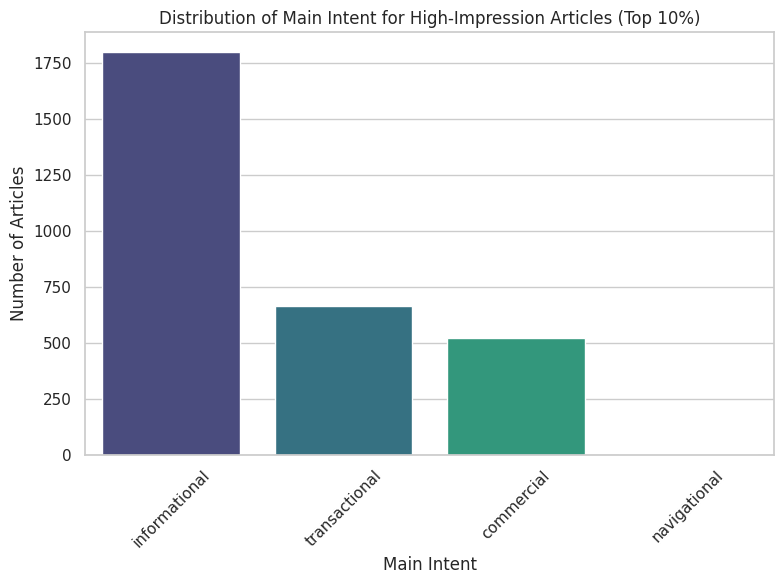

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for the distribution of 'main_intent'
plt.figure(figsize=(8, 6))
sns.barplot(x=intent_counts.index, y=intent_counts.values, hue=intent_counts.index, palette='viridis', legend=False)

# Add labels and title
plt.title('Distribution of Main Intent for High-Impression Articles (Top 10%)')
plt.xlabel('Main Intent')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

### Evaluate Tuned Model on DuckDB Dataset
Now let's see how our hyperparameter-tuned model performs on the large 60-day DuckDB warehouse data compared to the baseline and the un-tuned model.

In [34]:
# Predict using the TUNED pipeline
tuned_duckdb_predictions = best_pipeline.predict(X_duckdb)

# Because the target was raw impressions, we predict directly and ensure non-negativity
tuned_duckdb_predictions = np.maximum(tuned_duckdb_predictions, 0)

print("Predictions generated on DuckDB data using the Tuned Model.")

# Calculate metrics for the tuned model
tuned_model_metrics = calc_metrics(actual_duckdb, tuned_duckdb_predictions)

# Create an updated comparison DataFrame
updated_comparison_df = pd.DataFrame({
    'Model': ['Naive Baseline', 'Original XGBoost', 'Tuned XGBoost'],
    'MAE': [baseline_metrics['MAE'], model_metrics['MAE'], tuned_model_metrics['MAE']],
    'RMSE': [baseline_metrics['RMSE'], model_metrics['RMSE'], tuned_model_metrics['RMSE']],
    'R2': [baseline_metrics['R2'], model_metrics['R2'], tuned_model_metrics['R2']]
})

display(updated_comparison_df)

Predictions generated on DuckDB data using the Tuned Model.


,Model,MAE,RMSE,R2
0,Naive Baseline,1114.129217,4135.184804,0.626986
1,Original XGBoost,1099.210459,5235.358481,0.402100
2,Tuned XGBoost,1045.411134,5274.124217,0.393213


### Phase 3: Improve Target Formulation (Log Transformation)
Impressions data is highly skewed. Let's wrap our tuned pipeline in a `TransformedTargetRegressor` to predict on a logarithmic scale (`log1p`), which should significantly stabilize our RMSE by reducing the penalty of massive outliers.

In [35]:
from sklearn.compose import TransformedTargetRegressor
import numpy as np

# Wrap the tuned pipeline to transform the target variable during training/prediction
log_pipeline = TransformedTargetRegressor(
    regressor=best_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

print("Training log-transformed model on the training set...")
log_pipeline.fit(X_train, y_train)
print("Training complete.")

Training log-transformed model on the training set...
Training complete.


In [36]:
# Predict on the DuckDB evaluation set
log_duckdb_predictions = log_pipeline.predict(X_duckdb)

# Ensure no negative predictions
log_duckdb_predictions = np.maximum(log_duckdb_predictions, 0)

print("Predictions generated on DuckDB data using the Log-Transformed Model.")

# Calculate metrics
log_model_metrics = calc_metrics(actual_duckdb, log_duckdb_predictions)

# Create the final comparison DataFrame
final_comparison_df = pd.DataFrame({
    'Model': [
        'Naive Baseline',
        'Original XGBoost',
        'Tuned XGBoost',
        'Tuned XGBoost (log1p Target)'
    ],
    'MAE': [
        baseline_metrics['MAE'],
        model_metrics['MAE'],
        tuned_model_metrics['MAE'],
        log_model_metrics['MAE']
    ],
    'RMSE': [
        baseline_metrics['RMSE'],
        model_metrics['RMSE'],
        tuned_model_metrics['RMSE'],
        log_model_metrics['RMSE']
    ],
    'R2': [
        baseline_metrics['R2'],
        model_metrics['R2'],
        tuned_model_metrics['R2'],
        log_model_metrics['R2']
    ]
})

display(final_comparison_df)

Predictions generated on DuckDB data using the Log-Transformed Model.


,Model,MAE,RMSE,R2
0,Naive Baseline,1114.129217,4135.184804,0.626986
1,Original XGBoost,1099.210459,5235.358481,0.402100
2,Tuned XGBoost,1045.411134,5274.124217,0.393213
3,Tuned XGBoost (log1p Target),1028.302627,5321.354024,0.382297


### Tuned Model Visualizations
Let's visualize the errors (residuals) and the actual vs. predicted values specifically for the **Tuned XGBoost** model.

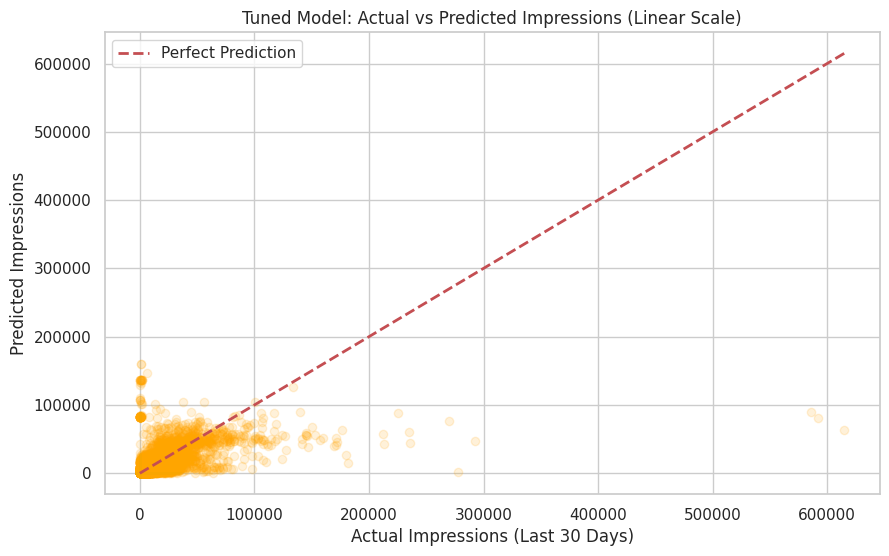

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Actual vs Predicted (Linear Scale) for Tuned Model
plt.figure(figsize=(10, 6))
plt.scatter(actual_duckdb, tuned_duckdb_predictions, alpha=0.15, color='orange')
max_val_tuned = max(np.max(actual_duckdb), np.max(tuned_duckdb_predictions))
plt.plot([0, max_val_tuned], [0, max_val_tuned], 'r--', lw=2, label='Perfect Prediction')
plt.title('Tuned Model: Actual vs Predicted Impressions (Linear Scale)')
plt.xlabel('Actual Impressions (Last 30 Days)')
plt.ylabel('Predicted Impressions')
plt.legend()
plt.show()

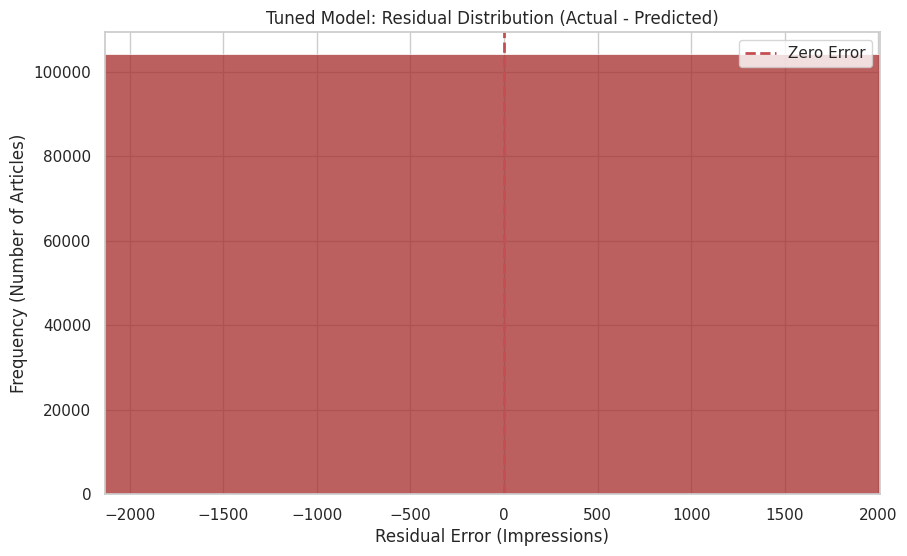

In [38]:
# 2. Residual Distribution for Tuned Model
tuned_residuals = actual_duckdb - tuned_duckdb_predictions

plt.figure(figsize=(10, 6))
sns.histplot(tuned_residuals, bins=100, color='brown')
plt.axvline(0, color='r', linestyle='--', lw=2, label='Zero Error')
plt.title('Tuned Model: Residual Distribution (Actual - Predicted)')
plt.xlabel('Residual Error (Impressions)')
plt.ylabel('Frequency (Number of Articles)')

# Zoom in on the bulk of the distribution to ignore extreme outliers
percentile_5 = np.percentile(tuned_residuals, 5)
percentile_95 = np.percentile(tuned_residuals, 95)
plt.xlim(percentile_5, percentile_95)

plt.legend()
plt.show()

### Phase 2: Build Better Features (Rich DuckDB Signals)
Let's construct a comprehensive dataset directly from the DuckDB warehouse. We will calculate advanced metrics like CTR, momentum, and position volatility using strict historical windows to completely prevent target leakage.

In [39]:
enriched_query = f"""
WITH bounds AS (
    SELECT MAX(CAST(f.report_date AS DATE)) AS end_date FROM {TABLES['fact_daily']} f
),
performance AS (
    SELECT
        f.client_hash_id,
        f.content_hash_id,
        -- Target (Last 30 Days)
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS target_impressions_30d,

        -- Recent Period (Prev 30 Days)
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_prev_30d,
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.gsc_clicks, 0) ELSE 0 END) AS clk_prev_30d,
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN COALESCE(f.ga4_sessions, 0) ELSE 0 END) AS ses_prev_30d,
        AVG(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN f.gsc_avg_position END) AS pos_prev_30d,
        STDDEV(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 60 DAY AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 30 DAY
                 THEN f.gsc_avg_position END) AS pos_volatility_30d,

        -- Historical Period (Prev 60 to 30 Days) for Momentum
        SUM(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 90 DAY AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 60 DAY
                 THEN COALESCE(f.gsc_impressions, 0) ELSE 0 END) AS imp_prev_60_to_30d,
        AVG(CASE WHEN CAST(f.report_date AS DATE) > b.end_date - INTERVAL 90 DAY AND CAST(f.report_date AS DATE) <= b.end_date - INTERVAL 60 DAY
                 THEN f.gsc_avg_position END) AS pos_prev_60_to_30d

    FROM {TABLES['fact_daily']} f
    CROSS JOIN bounds b
    WHERE CAST(f.report_date AS DATE) > b.end_date - INTERVAL 90 DAY
    GROUP BY f.client_hash_id, f.content_hash_id
    HAVING imp_prev_30d >= 100
)
SELECT
    p.*,
    (p.clk_prev_30d / NULLIF(p.imp_prev_30d, 0)) AS ctr_prev_30d,
    (p.ses_prev_30d / NULLIF(p.clk_prev_30d, 0)) AS session_rate_prev_30d,
    (p.imp_prev_30d / NULLIF(p.imp_prev_60_to_30d, 0)) AS traffic_momentum,
    (p.pos_prev_30d - p.pos_prev_60_to_30d) AS position_change,

    -- Content metadata
    c.search_volume,
    c.competition,
    c.cpc,
    c.word_count,
    c.char_count,
    DATE_DIFF('day', CAST(c.content_created_date AS DATE), (SELECT end_date FROM bounds)) AS content_age_days,
    c.competition_level,
    c.content_type,
    c.main_intent
FROM performance p
LEFT JOIN {TABLES['dim_content']} c ON p.content_hash_id = c.content_hash_id
"""

print("Extracting enriched feature set from DuckDB...")
enriched_data = con.sql(enriched_query).df()

# Merge with previously calculated query signals (qsignals)
enriched_data = enriched_data.merge(qsignals, on='content_hash_id', how='left')

print(f"Enriched dataset ready with {len(enriched_data):,} rows.")
display(enriched_data.head())

Extracting enriched feature set from DuckDB...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Enriched dataset ready with 111,247 rows.


,client_hash_id,content_hash_id,target_impressions_30d,imp_prev_30d,clk_prev_30d,ses_prev_30d,pos_prev_30d,pos_volatility_30d,imp_prev_60_to_30d,pos_prev_60_to_30d,...,content_age_days,competition_level,content_type,main_intent,visible_queries,rare_share,anon_share,top_query_impressions,kept_impressions,top_query_share
0,client_06d356715a8ff3b6,content_0059a4d4195810c9,845.0,1108.0,1.0,6.0,17.658602,13.364848,934.0,8.083561,...,75,LOW,keyword article,informational,12.0,0.057499,0.805681,68.0,395.0,0.172152
1,client_06d356715a8ff3b6,content_005b6b7f7b8dda7f,957.0,1535.0,1.0,6.0,9.986717,3.001665,735.0,9.640986,...,73,LOW,keyword article,informational,9.0,0.054540,0.898667,34.0,151.0,0.225166
2,client_06d356715a8ff3b6,content_00a34394d4ee05ce,142.0,248.0,2.0,12.0,29.464602,24.509420,0.0,NaN,...,53,LOW,keyword article,informational,1.0,0.187179,0.774359,15.0,15.0,1.000000
3,client_06d356715a8ff3b6,content_0153b7dedc3fc40d,695.0,2297.0,1.0,1.0,8.294681,4.791721,784.0,7.620390,...,75,LOW,keyword article,transactional,16.0,0.133210,0.616525,705.0,945.0,0.746032
4,client_06d356715a8ff3b6,content_0170639e18314d31,517.0,157.0,1.0,1.0,8.392896,4.886563,0.0,NaN,...,45,LOW,keyword article,informational,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
from sklearn.compose import TransformedTargetRegressor

# Clean Data
enriched_data = enriched_data.dropna(subset=['target_impressions_30d'])

# Features
RICH_NUMERIC = [
    'imp_prev_30d', 'clk_prev_30d', 'ses_prev_30d', 'pos_prev_30d', 'pos_volatility_30d',
    'imp_prev_60_to_30d', 'pos_prev_60_to_30d', 'ctr_prev_30d', 'session_rate_prev_30d',
    'traffic_momentum', 'position_change', 'search_volume', 'competition', 'cpc',
    'word_count', 'char_count', 'content_age_days', 'visible_queries', 'top_query_share'
]
RICH_CAT = ['competition_level', 'content_type', 'main_intent']

RICH_FEATURES = RICH_NUMERIC + RICH_CAT

X_rich = enriched_data[RICH_FEATURES]
y_rich = enriched_data['target_impressions_30d']

# Train-Test Split (using DuckDB data directly)
X_rich_train, X_rich_test, y_rich_train, y_rich_test = train_test_split(
    X_rich, y_rich, test_size=0.2, random_state=42
)

# Update Preprocessor
rich_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), RICH_NUMERIC),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), RICH_CAT),
    ]
)

# Pipeline with best params found earlier, and Log Transformation (Phase 3)
rich_pipeline = Pipeline(steps=[
    ("preprocessor", rich_preprocessor),
    ("regressor", XGBRegressor(random_state=42, n_estimators=100, max_depth=7, learning_rate=0.05, subsample=0.8))
])

log_rich_pipeline = TransformedTargetRegressor(
    regressor=rich_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

print("Training enriched model on DuckDB data...")
log_rich_pipeline.fit(X_rich_train, y_rich_train)
print("Training complete.")

Training enriched model on DuckDB data...
Training complete.


In [41]:
# Evaluate the Enriched Model
rich_y_pred = log_rich_pipeline.predict(X_rich_test)
rich_y_pred = np.maximum(rich_y_pred, 0)

rich_metrics = calc_metrics(y_rich_test, rich_y_pred)

# Calculate Naive Baseline on the same test set (using imp_prev_30d)
naive_test_preds = X_rich_test['imp_prev_30d'].fillna(0).to_numpy()
naive_test_metrics = calc_metrics(y_rich_test, naive_test_preds)

print("--- DuckDB Test Set Performance (Enriched Features) ---")
print(f"Naive MAE         : {naive_test_metrics['MAE']:,.2f}")
print(f"Enriched Model MAE: {rich_metrics['MAE']:,.2f}\n")

print(f"Naive RMSE         : {naive_test_metrics['RMSE']:,.2f}")
print(f"Enriched Model RMSE: {rich_metrics['RMSE']:,.2f}\n")

print(f"Naive R²         : {naive_test_metrics['R2']:.4f}")
print(f"Enriched Model R²: {rich_metrics['R2']:.4f}")

--- DuckDB Test Set Performance (Enriched Features) ---
Naive MAE         : 1,074.29
Enriched Model MAE: 689.02

Naive RMSE         : 3,171.81
Enriched Model RMSE: 4,380.92

Naive R²         : 0.7792
Enriched Model R²: 0.5788
